# Analysis

## Imports

The following librarys and methods are used in this analysis.

For visualisation of the data, I have used the matplotlib and seaborn libraries. seaborn is an extention of matplotlib lib and utilizes it's power to make vizualization more complex without making using it more complex. matplotlib is doing the work, but seaborn makes it easy!

Since I've timed some methods in my analysis, I used the performance counter perf_counter from the time library.

The sklearn library has done the most heavy lifting in this analysis. It's a beginner friendly library with most of the classical machine learning algorithms. It also provides ways to pre process the data and analyze the results.

In [ ]:
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from data_processing import DataProcessor

## Load data

In [ ]:
data = DataProcessor.load_data()

### Inspect data

In [3]:
data.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


Let's drop the nullvalue rows of the sex column. I believe sex has a lot of bearing on size and thus not want to estimate sex for the analysis.

In [5]:
data = data.dropna(subset=['sex'])

To gain some insights about the columns with string datatype, look at some graphs:

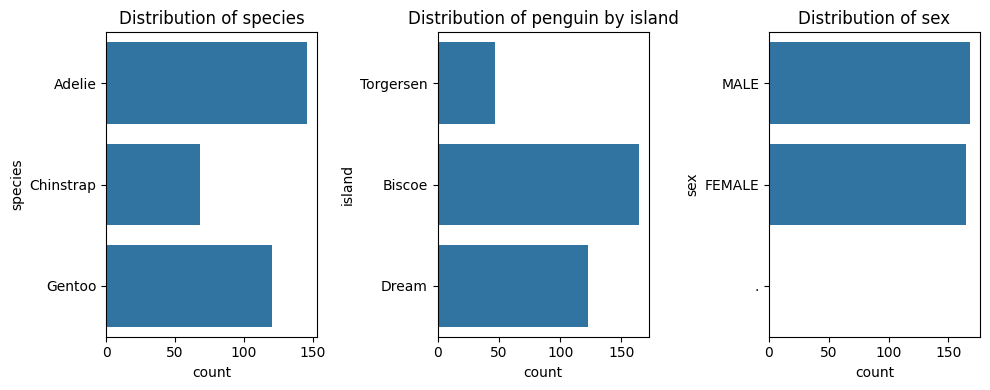

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

sns.countplot(data['species'], ax=ax[0])
ax[0].set_title('Distribution of species')

sns.countplot(data['island'], ax=ax[1])
ax[1].set_title('Distribution of penguin by island')

sns.countplot(data['sex'], ax=ax[2])
ax[2].set_title('Distribution of sex')

plt.tight_layout()
plt.show()

While looking at these graphs, it appears we have a strange value where 'sex' = '.'. Let's drop that too. The other graphs are fun to look at but nothing more for now.

In [7]:
data = data[data['sex'] != '.']

Check to see how it affected the other null values:

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   culmen_length_mm   333 non-null    float64
 3   culmen_depth_mm    333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


All nullvalues are gone and we can proceed without further null handling. 
Now on to making the data set even more useful for training and testing.

Let's update the 'sex' column to be 'female' and update to male = 0, and female = 1

In [9]:
data.rename(columns={'sex': 'female'}, inplace=True)
data['female'] = data['female'].map({'FEMALE':1, 'MALE':0,})

## Now let's have a look at some pairplots!

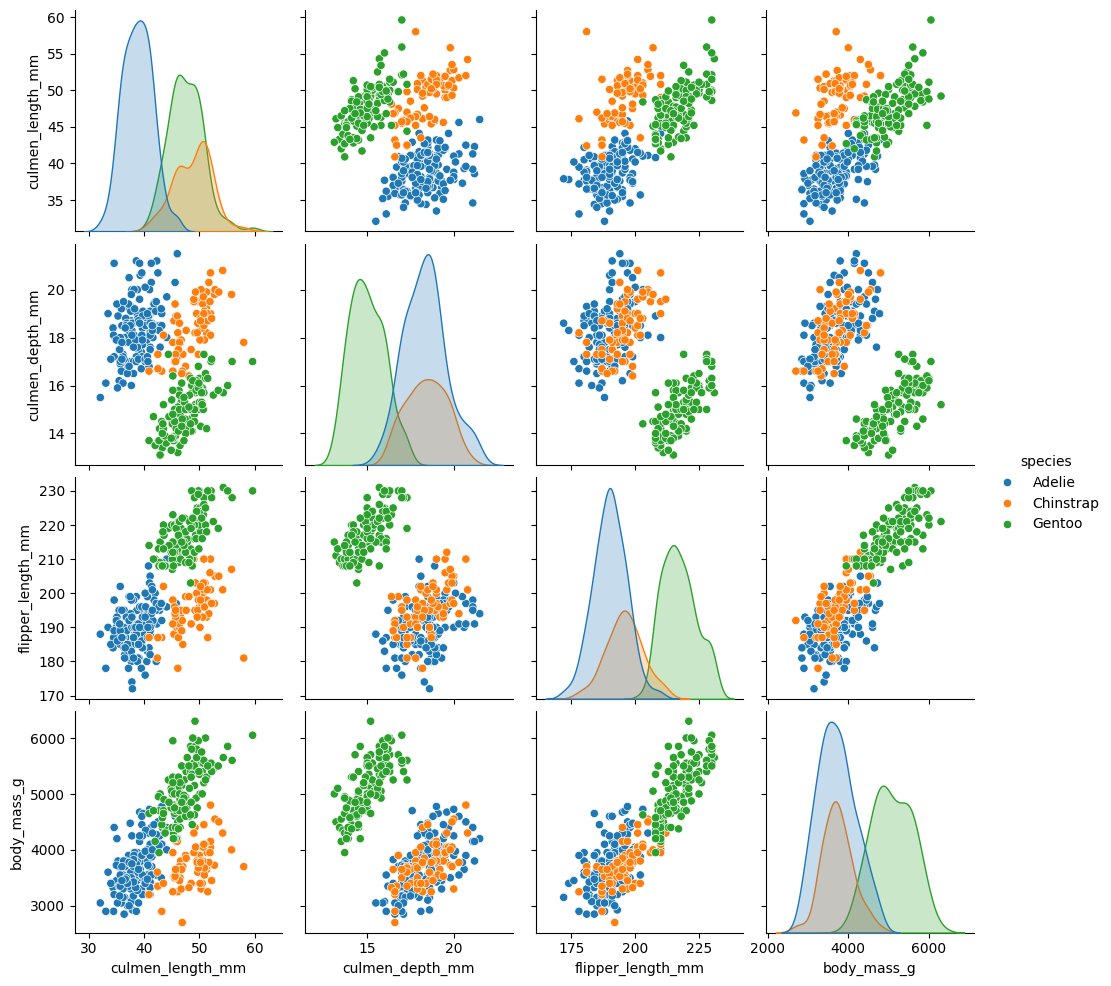

In [10]:
sns.pairplot(data[['culmen_length_mm', 
                   'culmen_depth_mm', 
                   'flipper_length_mm', 
                   'body_mass_g', 
                   'species']], 
            hue='species')
plt.show()

We can see that Gentoo sticks out a bit and we can expect Gentoo to be better predicted. However, Culmen Length seems to matter when it comes to separate Adelie and Chinstrap. Let's keep that in mind.

### Get dummy values

To get the data to work with all the models, make sure all columns are numerical.

In [11]:
species_order = {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}
data['species_encoded'] = data['species'].map(species_order)

island_order = {'Biscoe': 0, 'Dream': 1, 'Torgersen': 2}
data['island_encoded'] = data['island'].map(island_order)

data

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,female,species_encoded,island_encoded
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,0,0,2
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,1,0,2
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,1,0,2
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,1,0,2
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,0,0,2
...,...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,1,2,0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,1,2,0
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,0,2,0
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,1,2,0


## Modelling

Split the data into train data and test data

In [12]:
features = ['culmen_length_mm', 
            'culmen_depth_mm', 
            'flipper_length_mm', 
            'body_mass_g', 
            'female', 
            'island_encoded']
target = ['species_encoded']

X_train, X_test, y_train, y_test = train_test_split(data[features], 
                                                    data[target], 
                                                    test_size=0.2, 
                                                    random_state=42)

X_train

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,female,island_encoded
230,40.9,13.7,214.0,4650.0,1,0
84,37.3,17.8,191.0,3350.0,1,1
303,50.0,15.9,224.0,5350.0,0,0
22,35.9,19.2,189.0,3800.0,1,0
29,40.5,18.9,180.0,3950.0,0,0
...,...,...,...,...,...,...
194,50.9,19.1,196.0,3550.0,0,1
77,37.2,19.4,184.0,3900.0,0,2
112,39.7,17.7,193.0,3200.0,1,0
277,45.5,15.0,220.0,5000.0,0,0


### Scaling
Time to scale the data to not favour any specific feature unneccessarily. This seems important due to Body Mass being so much larger compared to the other measurements, and the fact that Culmen Length probably is the feature that will separate Adelie and Chinstrap penguins.

During trial runs this scaling was also proven to be essential and made the model many times mor accurate.

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [14]:
pd.DataFrame(X_train)

,0,1,2,3,4,5
0,-0.593727,-1.750939,0.935943,0.539737,1.038328,-0.917219
1,-1.261043,0.323107,-0.719956,-1.072364,1.038328,0.526451
2,1.093099,-0.638036,1.655899,1.407791,-0.963087,-0.917219
3,-1.520555,1.031318,-0.863947,-0.514329,1.038328,-0.917219
4,-0.667873,0.879558,-1.511908,-0.328318,-0.963087,-0.917219
...,...,...,...,...,...,...
261,1.259928,0.980731,-0.359978,-0.824349,-0.963087,0.526451
262,-1.279579,1.132491,-1.223925,-0.390321,-0.963087,1.970122
263,-0.816166,0.272520,-0.575965,-1.258376,1.038328,-0.917219
264,0.258954,-1.093315,1.367916,0.973764,-0.963087,-0.917219


### MPL Classifier

#### Set up the models and train

In [15]:
models = {
    'LOGISTIC REGRESSION': LogisticRegression(max_iter=10000),
    'RANDOM FOREST CLASSIFIER': RandomForestClassifier(max_depth=200),
    'SVC': SVC(max_iter=1000),
    'MLP CLASSIFIER': MLPClassifier(max_iter=1000)
}

for name, model in models.items():
    start = perf_counter()
    model.fit(X_train, y_train.values.ravel())
    end = perf_counter()
    print(f'Time elapsed to train {name}: {(end - start) * 1e3:.3f} ms')



Time elapsed to train LOGISTIC REGRESSION: 20.048 ms
Time elapsed to train RANDOM FOREST CLASSIFIER: 133.435 ms
Time elapsed to train SVC: 1.608 ms
Time elapsed to train MLP CLASSIFIER: 292.297 ms


It's worth noting that there are quit big differences in time for the models to train. Tre fastest model (SVC) are around 200 times faster than the slowest one (MPL Classifier). This might very well be viewed as super significant.

#### Analyze the models

LOGISTIC REGRESSION:
Mean accuracy:          0.993
Standard deviation:     0.009
Time elapsed to predict LOGISTIC REGRESSION: 0.181 ms
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67

Confusion matrix:


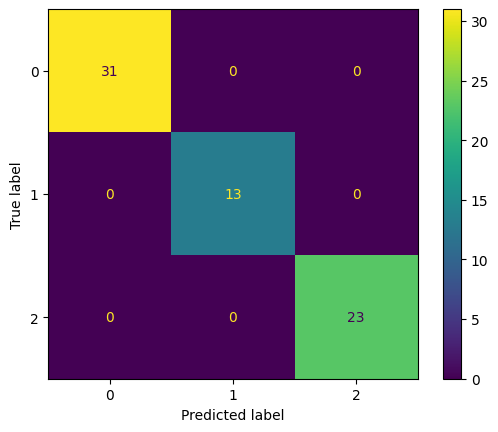


-------------------------------------------------------------------

RANDOM FOREST CLASSIFIER:
Mean accuracy:          0.981
Standard deviation:     0.000
Time elapsed to predict RANDOM FOREST CLASSIFIER: 6.054 ms
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67

Confusion matrix:


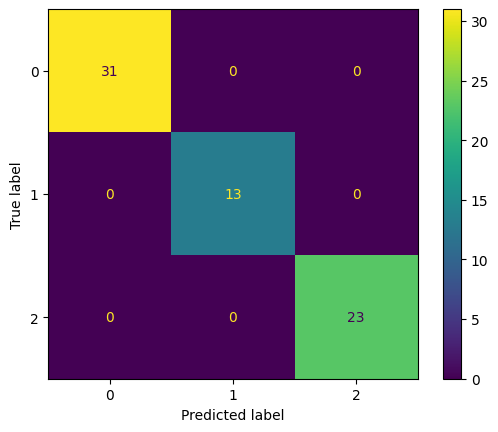


-------------------------------------------------------------------

SVC:
Mean accuracy:          0.993
Standard deviation:     0.009
Time elapsed to predict SVC: 0.370 ms
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67

Confusion matrix:


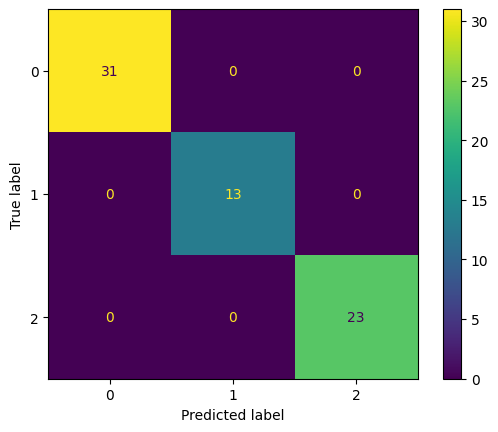


-------------------------------------------------------------------

MLP CLASSIFIER:
Mean accuracy:          0.989
Standard deviation:     0.009
Time elapsed to predict MLP CLASSIFIER: 0.464 ms
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67

Confusion matrix:


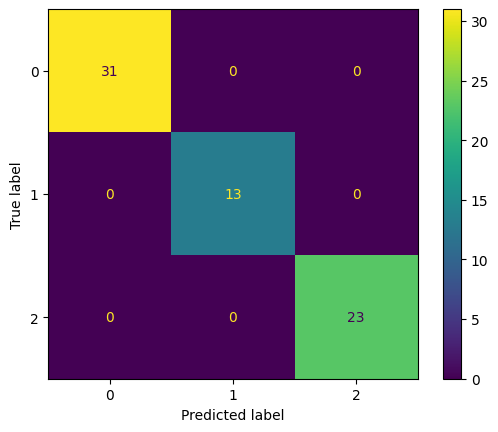


-------------------------------------------------------------------



In [16]:
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train.values.ravel())
    print(f'{name}:')
    print(f'Mean accuracy:          {scores.mean():.3f}')
    print(f'Standard deviation:     {scores.std():.3f}')

    start = perf_counter()

    y_predictions = model.predict(X_test)

    end = perf_counter()
    print(f'Time elapsed to predict {name}: {(end - start) * 1e3:.3f} ms')

    print('Classification report:')
    print(classification_report(y_test, y_predictions))

    print('Confusion matrix:')    
    cm = confusion_matrix(y_test, y_predictions)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)

    cm_display.plot()
    plt.show()


    print()
    print('-------------------------------------------------------------------')
    print()


## Comparison

Comparing the accuracy of the models is hard since all of the above models are scoring so high. The comparison looks at mean accuracy, standard deviation, precision, recall, f1-score, support, and a confusion martix, and all of them shows the same result. The accuracy of all the models are high.

It might in this case be more interesting to look at the time it takes to fit the models and evaluate them.

As stated before the SVC model is around 200 times faster to fit than the MPL Classifier. The other two are some where in between.

When predicting the values with the diffenent models the time difference is not as big. Linear Regression, SVC, and MPL Classifier are quite similar in time, while Random Forrest Classifier stands out a bit with being more than 10 times slower. Even though this number is quite high, it does not make as much difference in the end, since predicting new data often is done on much smaller batches than the training.